In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("data/dataset_financier_clean.csv")
df.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence_freq,banque_freq,lieu_freq
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,0.323,0.238,0.266
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,0.323,0.260,0.251
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,0.342,0.260,0.266
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,0.323,0.260,0.251
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,0.323,0.251,0.266


<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">I. ANN Building</p>

<a class="btn" href="#home">📅 ANN Constructing</a>

In [7]:
# importation des librairies
import tensorflow as tf
print(tf.__version__)

2.20.0


In [8]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [9]:
# séparer X et Y
X = df.drop('depenses', axis=1)
y = df['depenses']

In [10]:
# spliter X_train et x-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [11]:
# standardisation de X_train X_test, Y-train et Y-test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# je veux voir la taille de mon dataset
df.shape

(1000, 10)

In [13]:
# Build model
"""nous allons rajouter Dropout pour éviter le overfit en éteignant aléatoirement des neurones pendant l’entraînement
"""
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

e:\M2_s1\all_environements\ml_env1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# resumé du model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compilation
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)


In [16]:
"""restore_best_weights restaure automatiquement,
    les poids du modèle correspondant à l'epoch qui avait la meilleure performance sur val_loss"""
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min', # Sauvegarde quand val_loss DIMINUE
    verbose=1
)

In [17]:
# Entraînement avec tous les callbacks
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.2, #pour la validation pendant le training
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/300
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2415591.0000 - mae: 1473.6984 - mse: 2415591.0000
Epoch 1: val_loss improved from None to 2599883.25000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 2443682.0000 - mae: 1476.9463 - mse: 2443682.0000 - val_loss: 2599883.2500 - val_mae: 1525.9469 - val_mse: 2599883.2500 - learning_rate: 0.0010
Epoch 2/300
 5/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2516658.7500 - mae: 1470.0043 - mse: 2516658.7500
Epoch 2: val_loss improved from 2599883.25000 to 2597970.25000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2442315.5000 - mae: 1476.4810 - mse: 2442315.5000 - val_loss: 2597970.2500 - val_mae: 1525.3254 - val_mse: 2597970.2500 - learning_rate: 0.0010
Epoch 3/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2407904.5000 - mae: 1454.4231 - mse: 2407904.5000
Epoch 3: val_loss improved from 2597970.25000 to 2592918.50000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2439182.5000 - mae: 1475.4130 - mse: 2439182.5000 - val_loss: 2592918.5000 - val_mae: 1523.6829 - val_mse: 2592918.5000 - learning_rate: 0.0010
Epoch 4/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2407399.5000 - mae: 1478.5610 - mse: 2407399.5000
Epoch 4: val_loss improved from 2592918.50000 to 2581747.50000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2431827.7500 - mae: 1472.9155 - mse: 2431827.7500 - val_loss: 2581747.5000 - val_mae: 1520.0494 - val_mse: 2581747.5000 - learning_rate: 0.0010
Epoch 5/300
11/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2432377.4773 - mae: 1471.7690 - mse: 2432377.4773 
Epoch 5: val_loss improved from 2581747.50000 to 2558401.50000, saving model to best_model.h5


...

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 618203.7500 - mae: 654.0899 - mse: 618203.7500 - val_loss: 536826.1875 - val_mae: 594.8842 - val_mse: 536826.1875 - learning_rate: 0.0010
Epoch 15/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 646181.5000 - mae: 681.1206 - mse: 646181.5000
Epoch 15: val_loss improved from 536826.18750 to 382803.53125, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 423853.9062 - mae: 527.7734 - mse: 423853.9062 - val_loss: 382803.5312 - val_mae: 488.8044 - val_mse: 382803.5312 - learning_rate: 0.0010
Epoch 16/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 278180.8438 - mae: 401.1718 - mse: 278180.8438
Epoch 16: val_loss improved from 382803.53125 to 323550.56250, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 330134.7812 - mae: 466.0361 - mse: 330134.7812 - val_loss: 323550.5625 - val_mae: 448.3301 - val_mse: 323550.5625 - learning_rate: 0.0010
Epoch 17/300
15/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 304071.8396 - mae: 448.1639 - mse: 304071.8396  
Epoch 17: val_loss improved from 323550.56250 to 304389.34375, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 305232.1875 - mae: 448.1956 - mse: 305232.1875 - val_loss: 304389.3438 - val_mae: 434.2947 - val_mse: 304389.3438 - learning_rate: 0.0010
Epoch 18/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 182110.0938 - mae: 379.9471 - mse: 182110.0938
Epoch 18: val_loss improved from 304389.34375 to 302235.25000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 296011.5000 - mae: 441.9359 - mse: 296011.5000 - val_loss: 302235.2500 - val_mae: 431.6646 - val_mse: 302235.2500 - learning_rate: 0.0010
Epoch 19/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 371643.3438 - mae: 484.5547 - mse: 371643.3438
Epoch 19: val_loss did not improve from 302235.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 292621.2500 - mae: 439.6275 - mse: 292621.2500 - val_loss: 303454.9688 - val_mae: 431.3989 - val_mse: 303454.9688 - learning_rate: 0.0010
Epoch 20/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 351641.0312 - mae: 480.9484 - mse: 351641.0312
Epoch 20: val_loss did not improve from 302235.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 289990.4375 - mae: 437.6217 - mse: 289990.4375 - val_loss: 303504.3438 - val_mae: 430.8669 - val_mse: 303504.3438 - learning_rate: 0.0010
Epoch 21/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 168046.8906 - mae: 331.8815 - mse: 168046.8906
Epoch 21: val_

In [18]:
# quelles sont les critères d'évaluation de mon training
print(history.history.keys())

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse', 'learning_rate'])


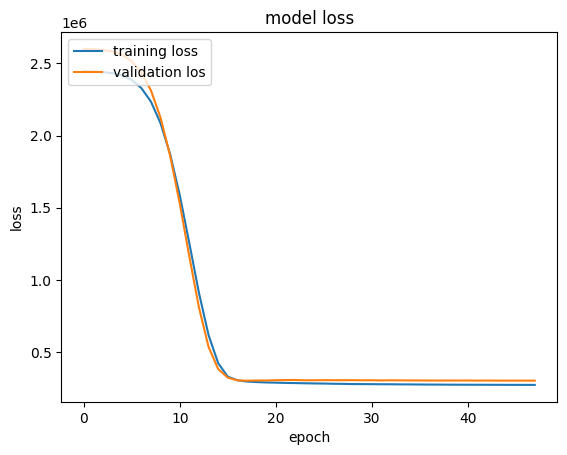

<module 'matplotlib.pyplot' from 'e:\\M2_s1\\all_environements\\ml_env1\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training loss', 'validation los'], loc='upper left')
plt.show()
plt

<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">III. ANN Evaluating</p>

<a class="btn" href="#home">📅 ANN Evaluating</a>

In [20]:
#Prediction
y_pred_train = model.predict(X_train)
y_pred_train

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[1450.5837 ],
       [1406.0286 ],
       [1545.2788 ],
       [1611.3964 ],
       [2106.8618 ],
       [1349.7085 ],
       [1506.5447 ],
       [1240.1259 ],
       [1517.0715 ],
       [1581.9362 ],
       [1406.2308 ],
       [1291.8766 ],
       [1669.9519 ],
       [1569.4609 ],
       [1380.1982 ],
       [1469.3427 ],
       [1451.4463 ],
       [1599.2347 ],
       [1258.8402 ],
       [1484.5393 ],
       [2108.2793 ],
       [1539.2882 ],
       [1252.7771 ],
       [1816.1298 ],
       [1650.9952 ],
       [1678.8651 ],
       [1609.2158 ],
       [1379.7579 ],
       [1625.5431 ],
       [1257.7843 ],
       [1364.013  ],
       [1735.2589 ],
       [1406.2102 ],
       [1738.9249 ],
       [1339.906  ],
       [1452.9038 ],
       [1294.719  ],
       [1234.1699 ],
       [1517.231  ],
       [1490.5114 ],
       [1673.1812 ],
       [1581.645  ],
       [1373.1526 ],
       [1018.7099 ],
       [1270.5032 ],
       [1459.2894 ],
       [1793.1458 ],
       [1548.

In [21]:
y_pred_test = model.predict(X_test)
y_pred_test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


array([[1775.4724 ],
       [1272.2407 ],
       [1383.4064 ],
       [1395.4086 ],
       [1468.5955 ],
       [1203.6259 ],
       [1682.5264 ],
       [1630.1102 ],
       [1333.0438 ],
       [1243.2279 ],
       [1606.1198 ],
       [1717.4509 ],
       [1278.1854 ],
       [1466.1494 ],
       [1139.7083 ],
       [1329.726  ],
       [1294.3196 ],
       [1210.8724 ],
       [1526.7712 ],
       [1542.3855 ],
       [1620.5029 ],
       [1231.4199 ],
       [1449.9355 ],
       [1639.2178 ],
       [1211.5294 ],
       [1297.8574 ],
       [1718.2427 ],
       [1406.5588 ],
       [1119.9229 ],
       [1708.2954 ],
       [1676.7819 ],
       [1766.7495 ],
       [1590.9031 ],
       [1288.3824 ],
       [1339.9568 ],
       [1576.4707 ],
       [1467.1732 ],
       [1276.6489 ],
       [1235.0054 ],
       [1521.4785 ],
       [1571.9761 ],
       [1260.7726 ],
       [1587.0913 ],
       [1479.3329 ],
       [1260.2928 ],
       [1298.9067 ],
       [1351.2738 ],
       [1397.

In [22]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
MSE = mean_squared_error(y_test, y_pred_test)
r2_score(y_train, y_pred_train)
RMSE = root_mean_squared_error(y_test, y_pred_test)

print(f"MSE: {MSE}")
print(f"R2 score: {r2_score(y_train, y_pred_train)}")
print(f"RMSE", RMSE)

MSE: 300555.43734975776
R2 score: -0.11578475539970534
RMSE 548.2293656397455
